In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make plots look nicer
plt.style.use("seaborn-v0_8-colorblind")
%matplotlib inline

# Paths (adjust SNOWGLOBES_ROOT if needed)

SNOWGLOBES_ROOT = Path("..").resolve()
XSCN_DIR = SNOWGLOBES_ROOT / "xscns"

In [2]:
def read_xscn(name,flavor='nue'):

    if flavor == 'nue':
        col = 1
    elif flavor =='numu':
        col = 2
    elif flavor == 'nuetau':
        col = 3
    elif flavor == 'nuebar':
        col = 4
    elif flavor == 'numubar':
        col = 5
    elif flavor == 'nutaubar':
        col = 6
        
    fname = XSCN_DIR / f"xs_{name}.dat"
    if not fname.is_file():
        raise FileNotFoundError(f"Cross-section file not found: {fname}")

    data = np.loadtxt(fname)
    if data.ndim == 1:
        data = data[None, :]

    energy = data[:, 0]
    energy = 10**energy# convert GeV -> MeV
    sigma = data[:, col]

    return energy, sigma

In [98]:
def plot_xscns(labels, names, flavors, colors, linestyles, logy=True, title=None):
   
    fig, ax = plt.subplots(figsize=(9, 5))

    for i in range(len(names)):
        name = names[i]
        flavor = flavors[i]
        E, sigma = read_xscn(name, flavor)
        ax.plot(E*1e3, sigma*E, label=labels[i], color=colors[i], linestyle=linestyles[i])  # convert GeV -> MeV on x-axis

    ax.set_xlabel("Neutrino energy [MeV]")
    ax.set_ylabel("Cross-section [10$^{-38}$ cm$^2$]")

    if logy:
        ax.set_yscale("log")

    if title is None:
        title = "Cross-section comparison"
    ax.set_title(title)
    ax.legend(ncol=3,loc='upper left')
    ax.grid(True)
    ax.set_xlim(0, 60)
    ax.set_ylim(1e-8, 1e2)

  
    return fig, ax

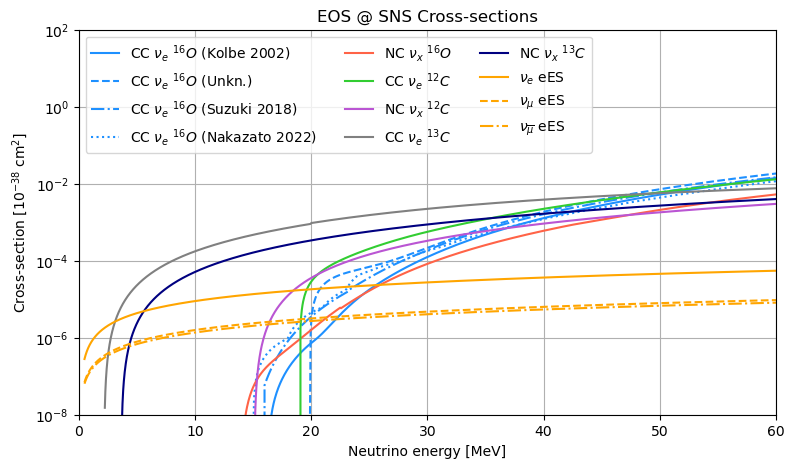

In [100]:
# Example: compare three O16 nu_e models
labels = [
    r"CC $\nu_{e}$ $^{16}O$ (Kolbe 2002)",
    r"CC $\nu_{e}$ $^{16}O$ (Unkn.)",
    r"CC $\nu_{e}$ $^{16}O$ (Suzuki 2018)",
    r"CC $\nu_{e}$ $^{16}O$ (Nakazato 2022)",
    r"NC $\nu_{x}$ $^{16}O$",
    r"CC $\nu_{e}$ $^{12}C$",
    r"NC $\nu_{x}$ $^{12}C$",
    r"CC $\nu_{e}$ $^{13}C$",
    r"NC $\nu_{x}$ $^{13}C$",
    r"$\nu_{e}$ eES",
    r"$\nu_{\mu}$ eES",
    r"$\nu_{\overline{\mu}}$ eES",
]

names = [
    "nue_O16",
    "nue_O16_2",
    "nue_O16_Suzuki2018",
    "nue_O16_Newton",
    "nc_nue_O16",
    "nue_C12",
    "nc_nue_C12",
    "nue_C13",
    "nc_nue_C13",
    "nue_e",
    "numu_e",
    "numubar_e",
]

flavors = [
    "nue",
    "nue",
    "nue",
    "nue",
    "nue",
    "nue",
    "nue",
    "nue",
    "nue",
    "nue",
    "numu",
    "numubar",
    "nue",
]

colors = [
    "dodgerblue",
    "dodgerblue",
    "dodgerblue",
    "dodgerblue",
    "tomato",
    "limegreen",
    "mediumorchid",
    "grey",
    "navy",
    "orange",
    "orange",
    "orange",


]

linestyles = [
    "-",
    "--",
    "-.",
    ":",
    "-",
    "-",
    "-",
    "-",
    "-",
    "-",
    "--",
    "-.",
]

fig, ax = plot_xscns(labels, names, flavors, colors, linestyles, logy=True, title=r"EOS @ SNS Cross-sections");